# Import Packages

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from synth_data.outcome_generation import generate_outcome, calibrate_intercept, make_stationarity_matrix
from ntcp_fit.utilities import sigmoid

# Generate Data

In [3]:
seed = 1  # For reproducibility

In [4]:
n_patients = 1000  # Number of patients to generate

In [5]:
data = pd.DataFrame({"ID": [f'SYNTH_{n}' for n in np.arange(1, n_patients + 1)]})

rng = np.random.default_rng(seed)

# Continuous variables: Gaussian independent
data["pATM"] = rng.normal(loc=57.8, scale=10, size=n_patients)
data["EUDr"] = rng.normal(loc=62, scale=10, size=n_patients)
data["EUDb"] = rng.normal(loc=68, scale=10, size=n_patients)

data["ATM"] = sigmoid( - (data["pATM"] - 57.8)/1.1 ) # Obtain radiosensitivity measure

# Coded SNPs: multinomial independent in {0, 1, 2}
data["SNP_1"] = rng.choice([0, 1, 2], size=n_patients, p=[0.60, 0.22, 0.18])
data["SNP_2"] = rng.choice([0, 1, 2], size=n_patients, p=[0.50, 0.30, 0.20])
data["SNP_3"] = rng.choice([0, 1, 2], size=n_patients, p=[0.70, 0.20, 0.10])
data["SNP_4"] = rng.choice([0, 1, 2], size=n_patients, p=[0.60, 0.10, 0.30])

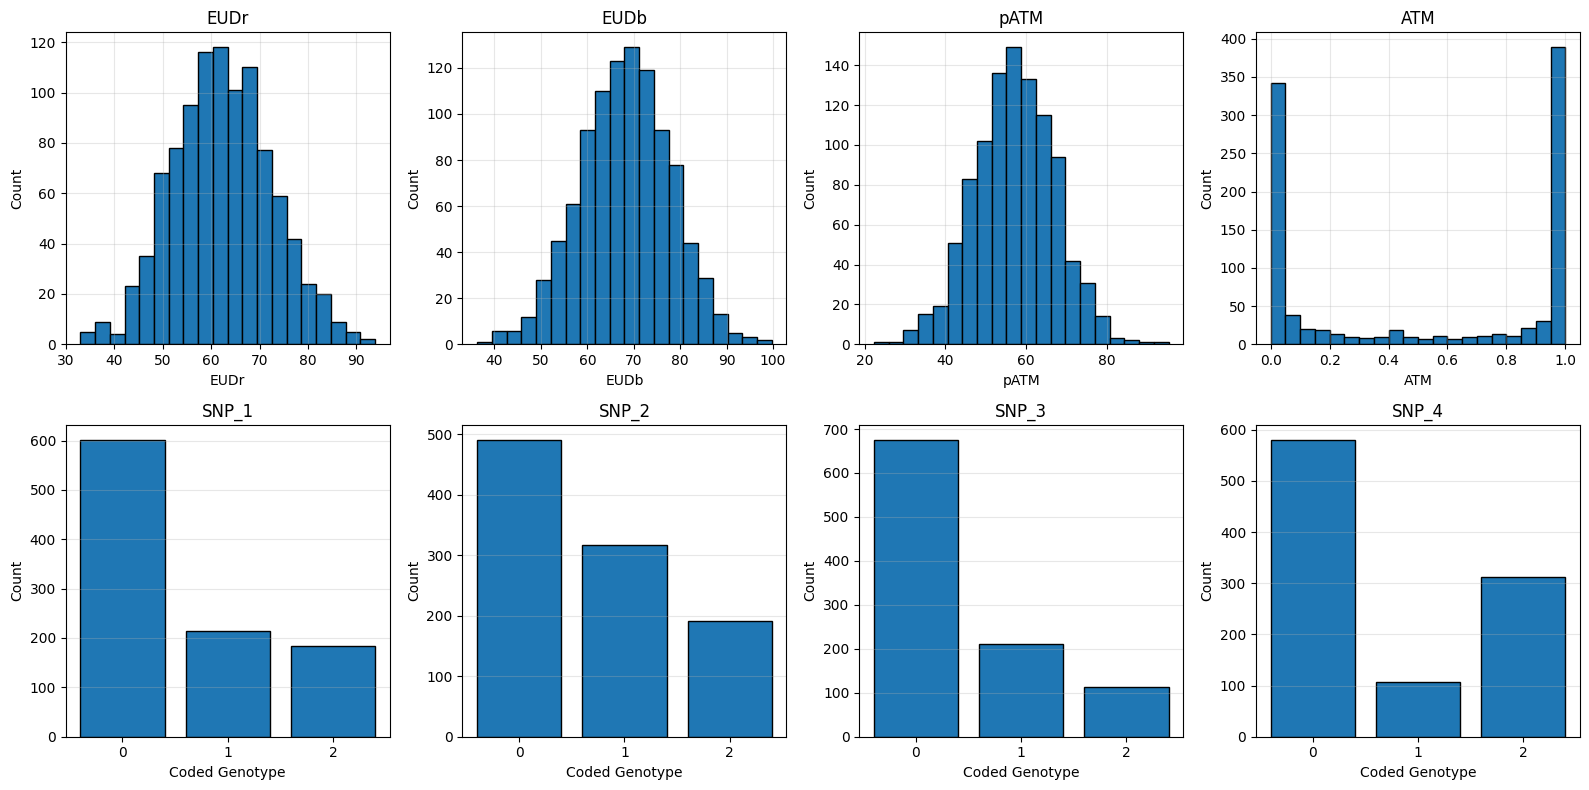

In [6]:
# Visualize generated data
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

continuous = ["EUDr", "EUDb", "pATM", "ATM"]

for ax, var in zip(axes[0], continuous):
    ax.hist(data[var], bins=20, edgecolor="black")
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

snps = ["SNP_1", "SNP_2", "SNP_3", "SNP_4"]

for ax, var in zip(axes[1], snps):
    counts = data[var].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, edgecolor="black")
    ax.set_title(var)
    ax.set_xlabel("Coded Genotype")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# GU outcome

In [7]:
# Generate urinary toxicity vector assuming the values of the model parameters

rng = np.random.default_rng(seed)

incidence_rate_gu = 0.3  # Incidence rate

beta_EUDb_gu = 0.02
beta_PRS_gu = 0.1
beta_EUDb_PRS_gu = 0.1
beta_EUDb_radiosensitivity_gu = 0.15

beta_snp1 = 0.8
beta_snp2 = -0.6

PRS_gu_no_int = (
    beta_snp1 * data["SNP_1"]
    + beta_snp2 * data["SNP_2"]
)

beta_0_PRS_gu = calibrate_intercept(
    PRS_gu_no_int,
    incidence_rate_gu,
)

PRS_gu = sigmoid(beta_0_PRS_gu + PRS_gu_no_int)

EUDb = data["EUDb"].values
radiosensitivity = data["ATM"].values
SNPs = data[["SNP_1", "SNP_2"]].values

EUDb_int = EUDb ** 0.5

scores_gu = (
    beta_EUDb_gu * EUDb
    + beta_PRS_gu * PRS_gu
    + beta_EUDb_PRS_gu * PRS_gu * EUDb_int
    + beta_EUDb_radiosensitivity_gu * radiosensitivity * EUDb_int
)

# Generate the outcome so that the true parameter values are approximately
# a stationary point of the log-likelihood while preserving the target incidence.

X_stat_gu = make_stationarity_matrix(
    EUD=data["EUDb"].values,
    PRS=PRS_gu,
    radiosensitivity=data["ATM"].values,
    SNPs=data[["SNP_1", "SNP_2"]].values,
    beta_PRS=beta_PRS_gu,
    beta_EUD_PRS=beta_EUDb_PRS_gu,
    beta_radiosensitivity=beta_EUDb_radiosensitivity_gu,
    a=0.5,
    fit_prs_params=True,
    fit_a=False,
    include_intercept=False,
)

outcome_gu, info_gu = generate_outcome(
    scores_no_intercept=scores_gu,
    incidence_rate=incidence_rate_gu,
    rng=rng,
    design_matrix=X_stat_gu,
    include_score=False,
    generation_method="tilted_search",
    incidence_tolerance=0.05,
    n_starts=500,
    n_iter_per_start=20000,
    flip_probability=0.7,
    return_info=True,
)

# GI outcome

In [8]:
# Generate intestinal toxicity vector assuming the values of the model parameters

rng = np.random.default_rng(seed)

incidence_rate_gi = 0.3  # Incidence rate

beta_EUDr_gi = 0.02
beta_PRS_gi = 0.1
beta_EUDr_PRS_gi = 0.1
beta_EUDr_radiosensitivity_gi = 0.1

beta_snp3 = 0.5
beta_snp4 = 0.3

PRS_gi_no_int = (
    beta_snp3 * data["SNP_3"]
    + beta_snp4 * data["SNP_4"]
)

beta_0_PRS_gi = calibrate_intercept(
    PRS_gi_no_int,
    incidence_rate_gi,
)

PRS_gi = sigmoid(beta_0_PRS_gi + PRS_gi_no_int)

EUDr = data["EUDr"].values
radiosensitivity = data["ATM"].values
SNPs = data[["SNP_3", "SNP_4"]].values

EUDr_int = EUDr ** 0.5

scores_gi = (
    beta_EUDr_gi * EUDr
    + beta_PRS_gi * PRS_gi
    + beta_EUDr_PRS_gi * PRS_gi * EUDr_int
    + beta_EUDr_radiosensitivity_gi * radiosensitivity * EUDr_int
)

# Generate the outcome so that the true parameter values are approximately
# a stationary point of the log-likelihood while preserving the target incidence.

X_stat_gi = make_stationarity_matrix(
    EUD=EUDr,
    PRS=PRS_gi,
    radiosensitivity=radiosensitivity,
    SNPs=SNPs,
    beta_PRS=beta_PRS_gi,
    beta_EUD_PRS=beta_EUDr_PRS_gi,
    beta_radiosensitivity=beta_EUDr_radiosensitivity_gi,
    a=0.5,
    fit_prs_params=True,
    fit_a=False,
    include_intercept=False,
)

outcome_gi, info_gi = generate_outcome(
    scores_no_intercept=scores_gi,
    incidence_rate=incidence_rate_gi,
    rng=rng,
    design_matrix=X_stat_gi,
    include_score=False,
    generation_method="tilted_search",
    incidence_tolerance=0.05,
    n_starts=500,
    n_iter_per_start=20000,
    flip_probability=0.7,
    return_info=True,
)

# Save data

In [9]:
data["outcome_U"] = outcome_gu
data["outcome_I"] = outcome_gi
data["outcome"] = outcome_gu + outcome_gi - outcome_gu * outcome_gi

data

,ID,pATM,EUDr,EUDb,ATM,SNP_1,SNP_2,SNP_3,SNP_4,outcome_U,outcome_I,outcome
0,SYNTH_1,61.255842,63.948396,66.331303,0.041421,0,0,0,1,0,0,0
1,SYNTH_2,66.016181,70.387180,74.246942,0.000570,2,0,1,1,0,0,0
2,SYNTH_3,61.104371,61.723507,59.357518,0.047247,2,0,0,0,0,0,0
3,SYNTH_4,44.768428,69.824318,67.471760,0.999993,0,1,2,2,1,0,1
4,SYNTH_5,66.853559,36.245570,76.386164,0.000266,2,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,SYNTH_996,54.412152,53.099544,69.645358,0.956054,1,0,0,0,0,1,1
996,SYNTH_997,33.615006,62.977421,79.271934,1.000000,0,0,0,2,1,1,1
997,SYNTH_998,57.038006,66.260566,62.536700,0.666572,1,1,1,2,1,0,1
998,SYNTH_999,53.828663,68.586356,93.962191,0.973669,2,2,1,0,1,1,1


In [10]:
data.to_excel(PROJECT_ROOT / "data" / "synth_data_1000pts.xlsx", index=False)